*CU Boulder GEOL 3600, fall semester 2025*

# Image Analysis

*Today's notebook:* **15_ImageAnalysis.ipynb**

*Same data file as Monday:* **boulder39p5N-106W_NASADEM.tif**

### Plan

- review assignment 2
- functions: passing by value versus reference
- more on gridded data and digital elevation models
- image analysis: Learning Objectives
  - learn about the use of images as gridded / raster data
  - learn about RGB color scale
  - one example of quantifying different colors
- introducing assignment 4: working with Landsat data

## Review of assignment 2

## Functions: passing by value vs. passing by reference

When a variable is passed as an argument to a function, does the function receive a **copy** of the data? Or is it the very same variable?

In Python, the answer is: it depends.

When you pass a variable with a simple data type, such as `int`, `float`, or `bool`, a copy of the variable is made when it is passed in.

Example:
```
def fn(x):
    x = 10
    print("In fn, the value is", x)

y = 152

fn(a)

print("The value of y is", y)
```

However, when you pass a `str`, `list`, `dict`, or other *object*, a **reference** to the variable is passed. This means that the *function has access to the very same data in the computer's memory*.

Example:
```
def listfn(thelist):
    thelist[0] = 9999
    thelist.append("salamander")

m = [152, "FRED"]

listfn(m)

print(m)
```

#### Pros and cons

- PRO: do not need to copy large data objects (e.g., a big numpy array)
- CON: functions are not "pure"; they can have side effects on shared data

In [16]:
def fn(x):
    x = 22
    print("x=", x)

y = 173

fn(y)

print("y is now", y)


x= 22
y is now 173


In [17]:
def anotherfn(input_list):
    input_list[0] = 'octopus'
    input_list.append('yellow submarine')
    print(input_list)

shopping = ['batteries', 'bananas']

anotherfn(shopping)

print("the shopping list is", shopping)

['octopus', 'bananas', 'yellow submarine']
the shopping list is ['octopus', 'bananas', 'yellow submarine']


## More on digital elevation models (DEMs)

In [18]:
# we need to bring back our earlier DEM for this
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("boulder39p5N-106W_NASADEM.tif")
topo = np.asarray(img)

#### Contouring
Matplotlib's contour() function creates a contour plot.

Here's an example:

```
plt.imshow(topo, cmap="terrain")
plt.contour(topo, levels=np.arange(1200, 4000, 500), colors="k")
```

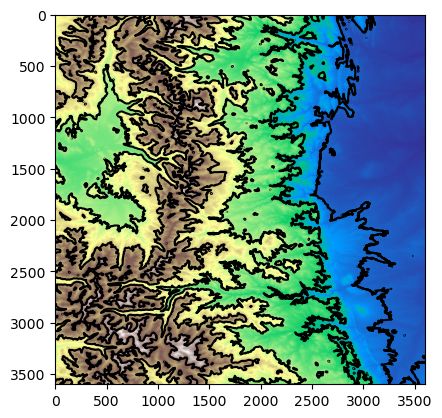

In [19]:
plt.imshow(topo, cmap="terrain")
plt.contour(topo, levels=np.arange(1200, 4000, 500), colors="k")

### Shaded relief
A shaded relief image, also known as a hillshade, displays a terrain as it might appear with lighting coming from a particular direction. The following function takes a 2D numpy array as an input parameter, and returns a hillshade image of the same size and shape:

In [9]:
def hillshade(z, azimuth=315.0, angle_altitude=45.0):
    """Generate a hillshade image from DEM.

    Notes: adapted from example on GeoExamples blog,
    published March 24, 2014, by Roger Veciana i Rovira.
    """
    x, y = np.gradient(z)
    slope = np.pi / 2.0 - np.arctan(np.sqrt(x**2 + y**2))  # slope gradient
    aspect = np.arctan2(-x, y)  # aspect
    azimuthrad = azimuth * np.pi / 180.0  # convert lighting azimuth to radians
    altituderad = angle_altitude * np.pi / 180.0  # convert lighting altitude to radians
    shaded = np.sin(altituderad) * np.sin(slope) + np.cos(altituderad) * np.cos(
        slope
    ) * np.cos(azimuthrad - aspect)
    return 255 * (shaded + 1) / 2  # return result scaled 0 to 255

### <div style="color:green">In-class practice</div>

Try applying the hillshade function to the Boulder DEM and displaying the resulting image with imshow().

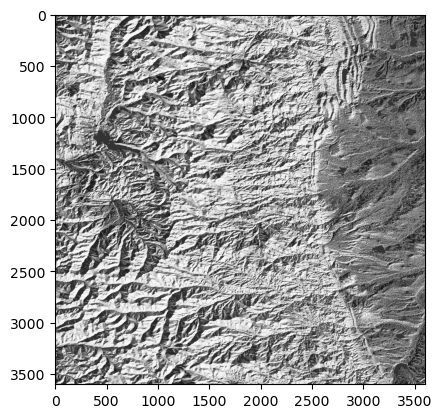

In [20]:
sh = hillshade(topo)
plt.imshow(sh, cmap="Grays")

### Using transparency to combine data layers

You can get a nice effect by plotting a hillshade on top of an elevation image, and applying some transparency to the hillshade so the elevation image shows through.

To apply transparency to an image, use the `alpha` keyword argument. It represents opacity (one minus transparency), and takes a number from 0 to 1. Smaller = more visibility of the underlying layer.

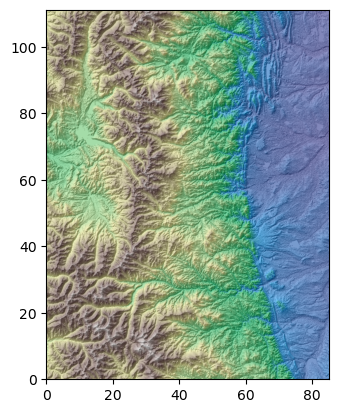

In [24]:
# To get a proper scale, define a 4-element list variable with your plot extent in km
xmax = 111.2 * np.cos(np.radians(40))
ymax = 111.2
plot_extent = [0, xmax, 0, ymax] # (complete and uncomment this line)

# Use imshow to display a terrain image with the "terrain" colormap (cmap).
# Include extent=plot_extent.
plt.imshow(topo, cmap="terrain", extent=plot_extent)

# Use imshow to display the hillshade on top of it, using the alpha parameter to set
# opacity to 50%. Use the "gray" colorap. Remember to use extent=plot_extent. 
plt.imshow(hs, cmap="gray", alpha=0.5, extent=plot_extent)

# Label your x and y axes


## Quiver plots and vector data

Slope magnitude and direction are a form of *vector data*. Other examples include windspeed and ocean current speed.

A **quiver plot** provides a way to visualize these data using arrows. Here's an example that makes a quiver plot of a small piece of the Boulder DEM around the flatirons:

```
flatirons = topo[1700:2100,2500:2700]
syf, sxf = np.gradient(flatirons, 31, 28)
plt.quiver(-sxf[::10,::10], -syf[::10,::10])
```

In [25]:
flatirons = topo[1700:2100,2500:2700]
syf, sxf = np.gradient(flatirons, 31, 28)

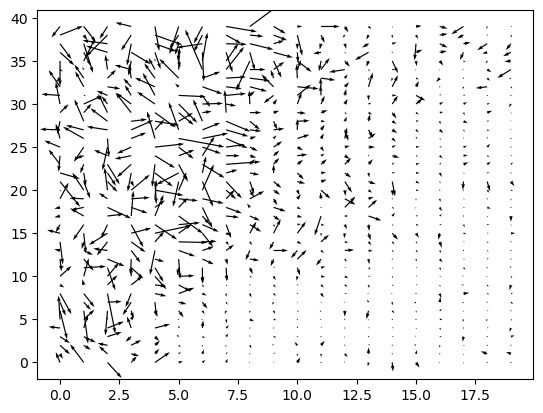

In [28]:
plt.quiver(-sxf[::10,::10], -syf[::10,::10])

## Image Analysis: How Computers Represent Photographs
An photograph is a recording of light reflected off something (typically refered to as a scene).  When a human observes something visually, it is light reflected off objects that activates specialized cells in the retina.  Photographs work the same way, using a variety of technologies to substitute for the cells of the retina.  Traditional film photography uses a film full of light-sensitive silver salt crystal, part of which becomes metallic silver when exposed to light.  Digital photography uses an array of photosensitive circuits that record the ammount of light.  In either case, what you are left with is (typically but not necessarily) a rectangle that represents the amount of light reflected from a captured scene.

### Rasters
The result of a digital image is called a "raster" an array of values representing the ammount of light at each position.  Below is a sample raster repreented in python as a list of lists of integers.  The first list is the upper row of pixels in our image.  The top left pixel has a value of 255, meaning very bright.  The bottom right has a value of 60, rather dark. 

In [1]:
image = [[255,200,180,180,180],
         [200,200,100,100,100],
         [180,180,80, 100, 80],
         [170,170,70, 100, 60],
         [160,160,60, 100, 60]]

A typical pixel in a computer image will have values that range from 0 to 255.  Think about what we learned about how computers represent numbers.  What does this mean about the underlying data structure of a pixel?

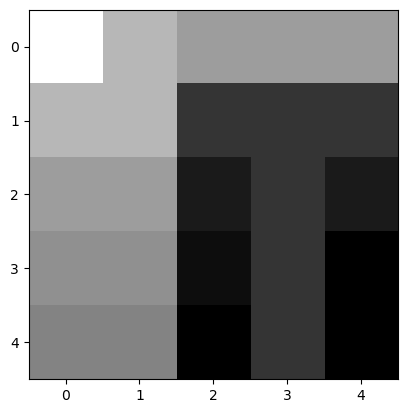

In [4]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap="gray")

### Color photography
The sensors (silver salt or digitial circuit) record the *amount* of light that hit them, not necessarily the *color* of light.  So how do we get color images?  Humans see color because specific types of cells in the retina are sensitive to specific wavelengths of light.  Humans are sensitive to red, green, and blue light (see below).
![human color sensitivity](https://upload.wikimedia.org/wikipedia/commons/f/f1/1416_Color_Sensitivity.svg)
Our eyes take in the ammount of red, green, and blue light in what we see, and construct color based on that.  We can mimic that with a digital image by recording the ammount of red, green, and blue light.  This can be done by filtering out different types of light, but you can think of a digital camera as, like an eye, having three different types of sensors.  When a computer displays an image, rather than each pixel representing a certain ammount of light, like in our example above, each "pixel" is three lights, one red, one green, and one blue.  Each light as a brightness that corresponds to the relative ammount of that color light in that part of the scene.  Put your phone screen under a microscope sometime, you'll see that it's actually made up of a bunch of red, green,. and blue lights!
#### Color rasters
But how do we store this on a computer?  Whereas before, we had a list of lists, or an array where each value was the ammount of light reflected from a scene, instead we could have each value be a tuple contaning the ammount of red, green, and blue light!

In [13]:
color_image = [[(120, 0, 120), (120, 10, 120), (120, 20, 120)],
               [(130, 0, 120), (120, 10, 130), (130, 20, 130)],
               [(140, 0, 120), (130, 10, 130), (140, 20, 140)]]

### RGB Color Scale

RGB stands for Red, Green, Blue. The color scale constructs all colors from a combination of the three primary colors. The red, green and blue use 8 bits each, which have integer values from 0 to 255. <br>
This makes 256 * 256 * 256 = 16,777,216 possible colors.

Note that there is also a Hex code. 
This is just a different notation of the same RGB combination. The hexidecimal notation  is easier to read than the binary representation, it has a # and a combination of letters and numbers for each color. This is commonly used in HTML code (on the web).

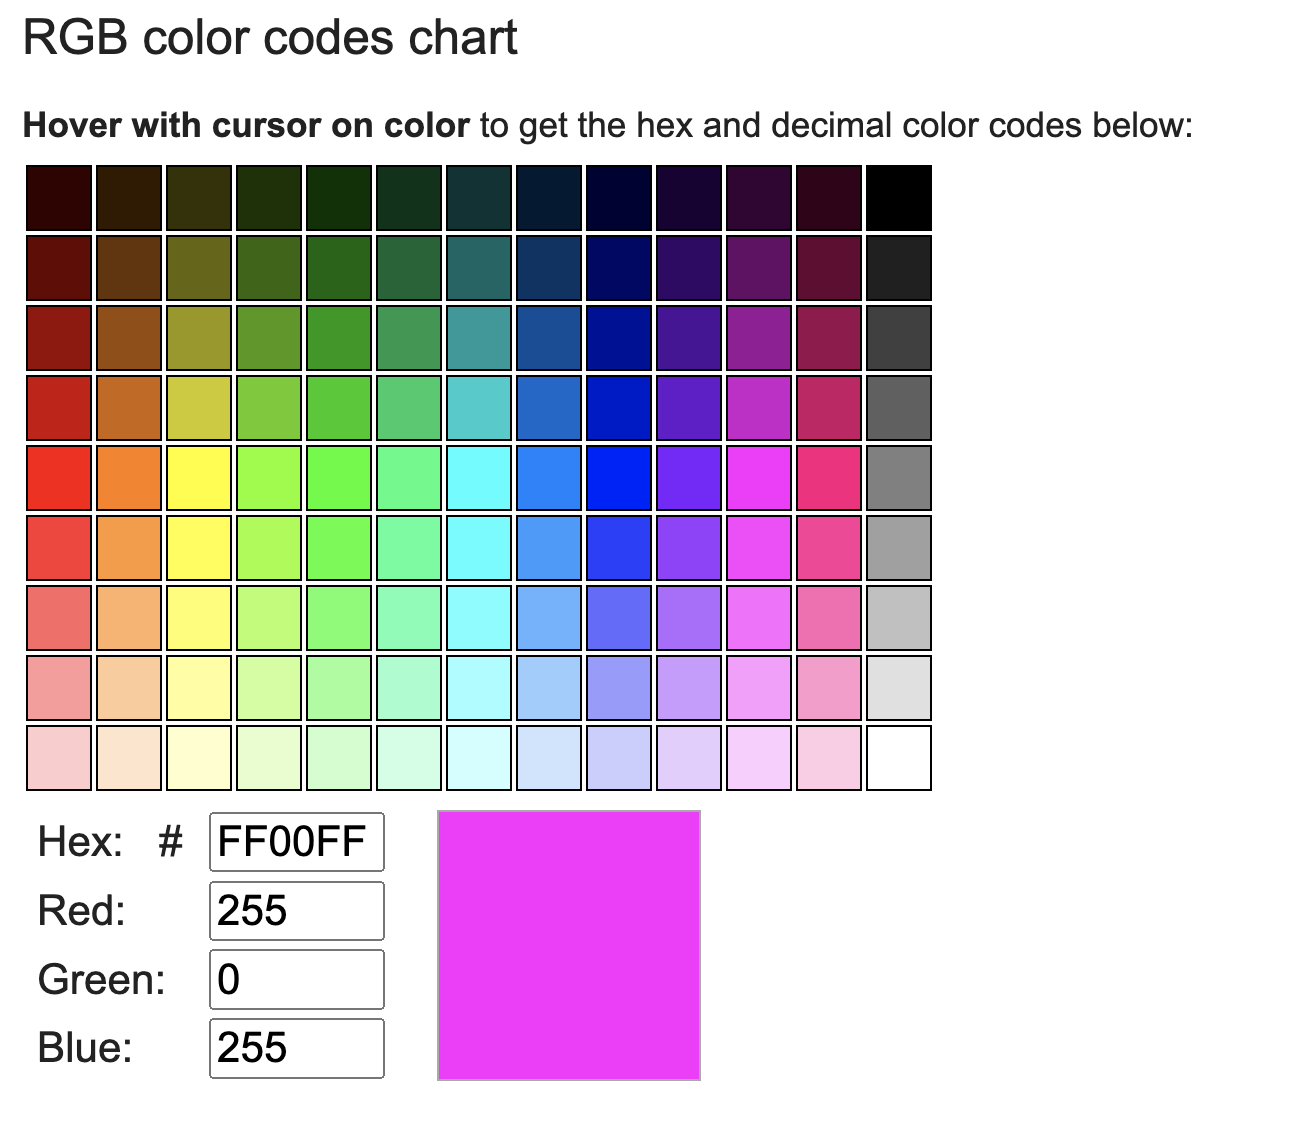

* Image Courtesy: https://www.rapidtables.com/web/color/RGB_Color.html

### From images to spectral data
Sure humans typically only distinguish between red, green, and blue light, but we can build sensors to distinguish between all sorts of different parts of the electromagnetic spectrum.
![the electromagnetic spectrum](https://upload.wikimedia.org/wikipedia/commons/thumb/2/25/Electromagnetic-Spectrum.svg/1024px-Electromagnetic-Spectrum.svg.png)
A common "band" of the spectrum of interest to a wide range of scientists is the "infrared" section, netween visible light and radio waves.  This section of the spectrum can capture thermal radiation, like the heat off of a body (ever seen a picture from "night vision" goggles?" and has a wide range of applications, including vegetation health.

The satellite (Landsat 8) that captured the satellite image near Boulder contains a few bands beyond the visible spectrum.  We've included the near infrared band, but read about the Landsat satelite and other bands it includes.  Do you have any ideas about how you could use other bands?